# Práctica 3 — GPC con enfoque intuitivo e industrial

**Objetivo:** comprender qué hace un GPC sin convertir la práctica en un ejercicio de manipulación polinómica.

Flujo de trabajo:

**datos → modelo → predicción → optimización → primera acción → repetir**

En lugar de partir directamente de los polinomios $A$ y $B$, generaremos datos de una planta que trataremos como **desconocida**, identificaremos un modelo sencillo y lo utilizaremos dentro del controlador.


## 1. Qué cambia respecto a MAC y DMC

MAC y DMC describen el proceso mediante colecciones de coeficientes obtenidos de respuestas experimentales. GPC utiliza un **modelo paramétrico compacto**.

Para esta práctica basta con interpretar:

- $A$: cómo influye el pasado de la salida.
- $B$: cómo influye el pasado de la entrada.
- $d$: retardo entrada–salida.
- $\Delta u$: cuánto cambiamos la acción de control.

La formulación CARIMA clásica y las ecuaciones diofánticas se comentarán en clase, pero **no las resolveremos a mano**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

np.random.seed(7)


## 2. Generamos datos de una planta «desconocida»

El profesor conoce la planta usada para generar los datos; el controlador no. Esto reproduce mejor el flujo de trabajo industrial: medimos $u(k)$ e $y(k)$ y tratamos de obtener un modelo útil para predecir.


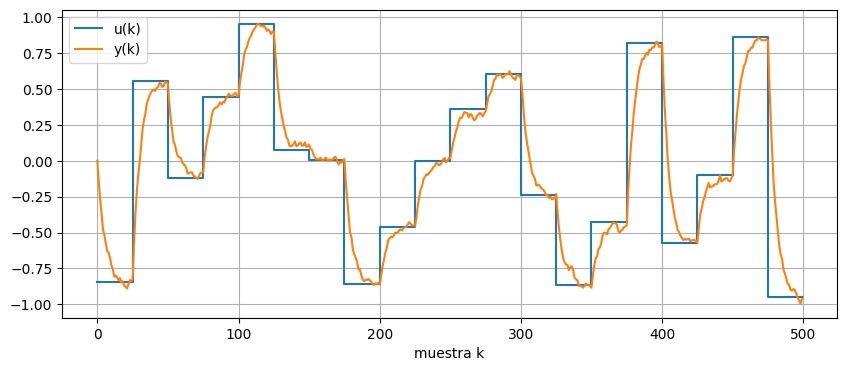

In [2]:
# Planta real SOLO para generar datos
# y(k) = a*y(k-1) + b*u(k-1) + perturbación
a_real = 0.82
b_real = 0.18
N = 500

# Entrada de identificación: cambios de nivel suficientemente ricos
u_id = np.zeros(N)
level = 0.0
for k in range(0, N, 25):
    level = np.random.uniform(-1.0, 1.0)
    u_id[k:k+25] = level

y_id = np.zeros(N)
for k in range(1, N):
    y_id[k] = a_real*y_id[k-1] + b_real*u_id[k-1] + 0.015*np.random.randn()

t = np.arange(N)
plt.figure(figsize=(10,4))
plt.step(t, u_id, where='post', label='u(k)')
plt.plot(t, y_id, label='y(k)')
plt.xlabel('muestra k'); plt.grid(True); plt.legend(); plt.show()


### Pregunta para clase

¿Sería buena idea identificar el modelo usando una entrada prácticamente constante?

<details>
<summary><b>Mostrar respuesta</b></summary>

No. Si la entrada apenas cambia, el proceso queda **poco excitado** y los datos contienen poca información sobre su dinámica.

En esas condiciones resulta difícil distinguir correctamente:

- cuánto de la salida se debe a la dinámica propia del proceso;
- cuánto se debe a la entrada;
- cuánto corresponde a ruido o perturbaciones.

Para identificar un modelo útil para predicción interesa que la señal de entrada recorra suficientemente la dinámica relevante del proceso, siempre dentro de límites seguros de operación.

</details>


## 3. Identificación sencilla del modelo

Usaremos un modelo ARX de primer orden:

\begin{align*}
y(k) = a\,y(k-1) + b\,u(k-1)
\end{align*}

Los parámetros se estiman por mínimos cuadrados. La intención no es estudiar identificación de sistemas en profundidad, sino hacer visible que **el modelo del GPC debe obtenerse de algún sitio**.


In [3]:
Phi = np.column_stack([y_id[:-1], u_id[:-1]])
Y = y_id[1:]
theta, *_ = np.linalg.lstsq(Phi, Y, rcond=None)
a_hat, b_hat = theta

print(f"a identificado = {a_hat:.4f}")
print(f"b identificado = {b_hat:.4f}")


a identificado = 0.8183
b identificado = 0.1825


## 4. ¿El modelo es suficientemente bueno?

Antes de diseñar el controlador, validamos. Un modelo puede ajustar bien unos datos y, aun así, predecir mal en otras condiciones.


RMSE de simulación = 0.0237


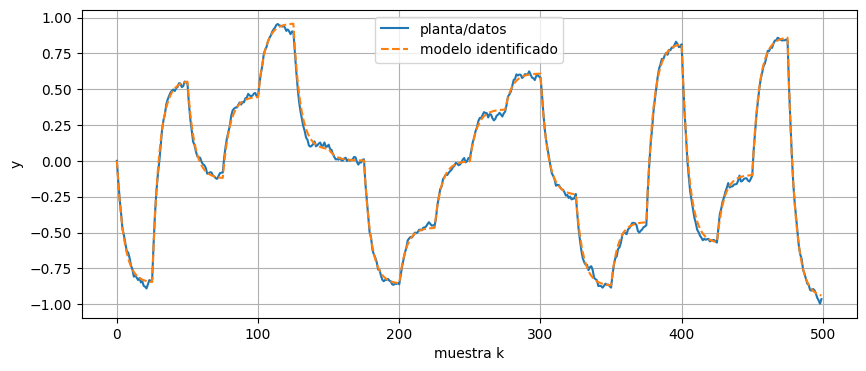

In [4]:
y_hat = np.zeros(N)
for k in range(1, N):
    y_hat[k] = a_hat*y_hat[k-1] + b_hat*u_id[k-1]

rmse = np.sqrt(np.mean((y_id-y_hat)**2))
print(f"RMSE de simulación = {rmse:.4f}")

plt.figure(figsize=(10,4))
plt.plot(y_id, label='planta/datos')
plt.plot(y_hat, '--', label='modelo identificado')
plt.xlabel('muestra k'); plt.ylabel('y')
plt.grid(True); plt.legend(); plt.show()


## 5. El predictor: la idea esencial de GPC

En cada instante imaginamos varias acciones futuras y usamos el modelo para responder:

> **Si aplico estos cambios de entrada, ¿cómo evolucionará la salida durante los próximos pasos?**

La implementación siguiente construye esa predicción directamente mediante simulación del modelo identificado. Así evitamos que la ecuación diofántica oculte la idea física.


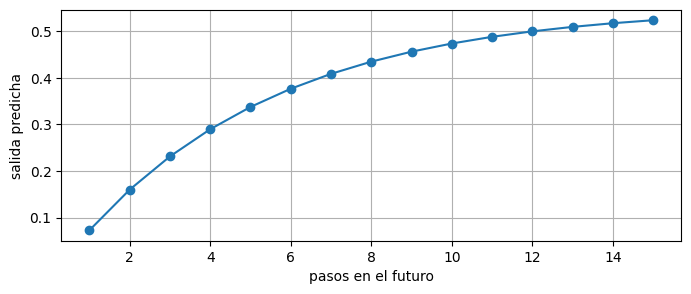

In [5]:
def predict_outputs(y0, u_prev, du_seq, a, b, Hp):
    """Predice Hp salidas suponiendo que, tras du_seq, Δu=0."""
    y = float(y0)
    u = float(u_prev)
    pred = []
    for j in range(Hp):
        if j < len(du_seq):
            u += du_seq[j]
        y = a*y + b*u
        pred.append(y)
    return np.asarray(pred)

# Ejemplo visual
Hp = 15
du_example = np.array([0.4, 0.15, 0.0])
yp = predict_outputs(0.0, 0.0, du_example, a_hat, b_hat, Hp)
plt.figure(figsize=(8,3))
plt.plot(np.arange(1,Hp+1), yp, 'o-')
plt.xlabel('pasos en el futuro'); plt.ylabel('salida predicha')
plt.grid(True); plt.show()


## 6. Qué optimiza el controlador

Solo necesitamos retener dos objetivos:

1. que la salida predicha se acerque a la referencia;
2. que los cambios de entrada no sean innecesariamente bruscos.

De forma compacta:

\begin{align*}
J = \text{error futuro} + \lambda\,\text{esfuerzo de control}
\end{align*}

$\lambda$ actúa como un mando de **agresividad**: pequeño → seguimiento rápido; grande → movimientos más suaves.


In [6]:
def prediction_matrix(y, u_prev, a, b, Hp, Hu):
    f = predict_outputs(y, u_prev, np.zeros(Hu), a, b, Hp)
    G = np.zeros((Hp, Hu))
    for j in range(Hu):
        du = np.zeros(Hu)
        du[j] = 1.0
        G[:, j] = predict_outputs(y, u_prev, du, a, b, Hp) - f
    return f, G

def gpc_move(y, u_prev, ref_future, a, b, Hp=15, Hu=3, lam=1.0):
    f, G = prediction_matrix(y, u_prev, a, b, Hp, Hu)
    H = G.T @ G + lam*np.eye(Hu)
    rhs = G.T @ (ref_future - f)
    du_opt = np.linalg.solve(H, rhs)
    return du_opt[0], f, G


## 7. Simulación en horizonte deslizante

Calculamos una secuencia óptima, **aplicamos solo el primer incremento** y repetimos todo en la siguiente muestra.


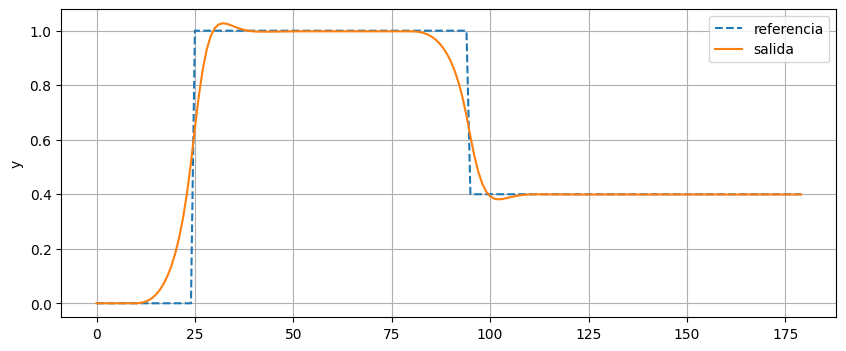

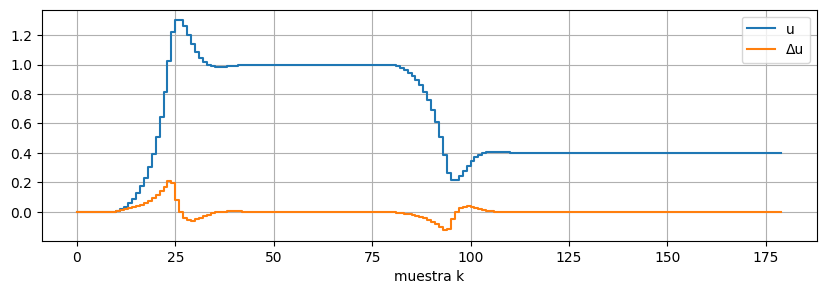

In [7]:
def simulate_gpc(a_model, b_model, lam=1.0, Hp=15, Hu=3,
                 a_plant=a_real, b_plant=b_real, disturbance=False):
    Nsim = 180
    r = np.zeros(Nsim + Hp + 1)
    r[25:95] = 1.0
    r[95:] = 0.4

    y = np.zeros(Nsim)
    u = np.zeros(Nsim)
    du = np.zeros(Nsim)

    for k in range(1, Nsim):
        ref_future = r[k+1:k+1+Hp]
        du[k], _, _ = gpc_move(y[k-1], u[k-1], ref_future,
                               a_model, b_model, Hp, Hu, lam)
        u[k] = u[k-1] + du[k]
        d = 0.12 if (disturbance and 110 <= k < 135) else 0.0
        y[k] = a_plant*y[k-1] + b_plant*u[k-1] + d

    return r[:Nsim], y, u, du

r,y,u,du = simulate_gpc(a_hat,b_hat,lam=1.0)

plt.figure(figsize=(10,4))
plt.plot(r, '--', label='referencia')
plt.plot(y, label='salida')
plt.grid(True); plt.legend(); plt.ylabel('y'); plt.show()

plt.figure(figsize=(10,3))
plt.step(np.arange(len(u)),u,where='post',label='u')
plt.step(np.arange(len(du)),du,where='post',label='Δu')
plt.grid(True); plt.legend(); plt.xlabel('muestra k'); plt.show()


## 8. Experimento 1 — efecto de $\lambda$

Ejecuta varios valores. Antes de mirar la gráfica, formula una predicción.

**Pregunta:** ¿qué esperas que ocurra al aumentar $\lambda$?

<details>
<summary><b>Mostrar respuesta</b></summary>

Al aumentar $\lambda$ damos más importancia a evitar cambios bruscos de la acción de control.

Por tanto, esperamos:

- menores valores de $\Delta u$;
- una acción de control más suave;
- generalmente, una respuesta más lenta;
- menor esfuerzo sobre el actuador.

Si $\lambda$ es demasiado pequeño, el controlador puede resultar excesivamente agresivo.

</details>


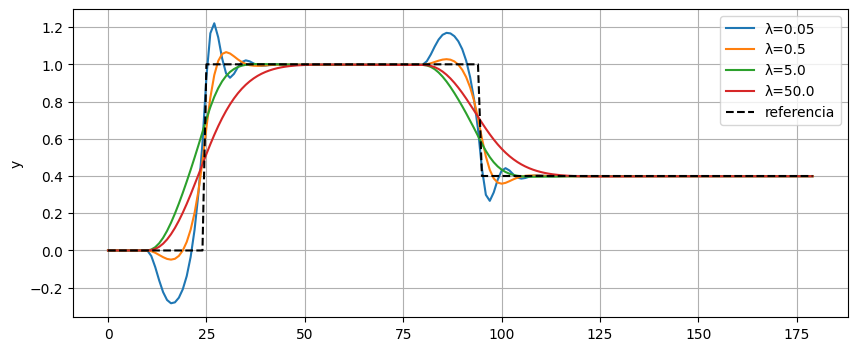

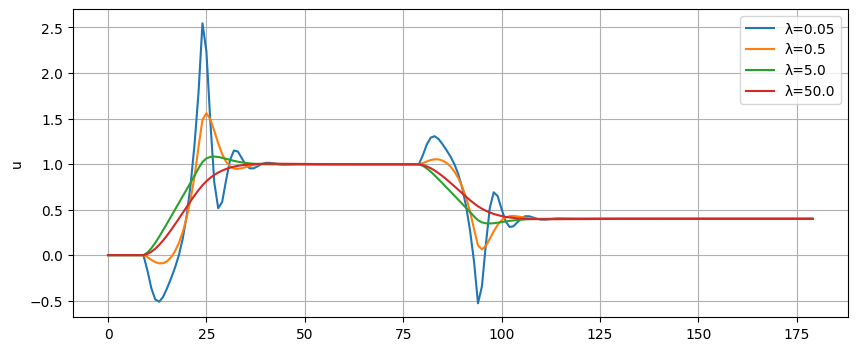

In [15]:
plt.figure(figsize=(10,4))
for lam in [0.05, 0.5, 5.0, 50.0]:
    r,y,u,du = simulate_gpc(a_hat,b_hat,lam=lam)
    plt.plot(y,label=f'λ={lam}')
plt.plot(r,'k--',label='referencia')
plt.grid(True); plt.legend(); plt.ylabel('y'); plt.show()

plt.figure(figsize=(10,4))
for lam in [0.05, 0.5, 5.0, 50.0]:
    r,y,u,du = simulate_gpc(a_hat,b_hat,lam=lam)
    plt.plot(u,label=f'λ={lam}')
#plt.plot(r,'k--',label='referencia')
plt.grid(True); plt.legend(); plt.ylabel('u'); plt.show()


<details>
<summary><b>Mostrar respuesta</b></summary>

Un $\lambda$ pequeño permite cambios de control mayores y suele acelerar el seguimiento. Un $\lambda$ grande penaliza esos movimientos y produce una respuesta más suave, normalmente más lenta.

La elección no consiste en «hacer el error mínimo a cualquier precio», sino en encontrar un compromiso compatible con los actuadores, el proceso y los objetivos de operación.

</details>


## 9. Experimento 2 — horizonte de predicción

Compara horizontes cortos y largos. Un horizonte largo permite «ver» más futuro, pero no convierte un modelo incorrecto en uno bueno.


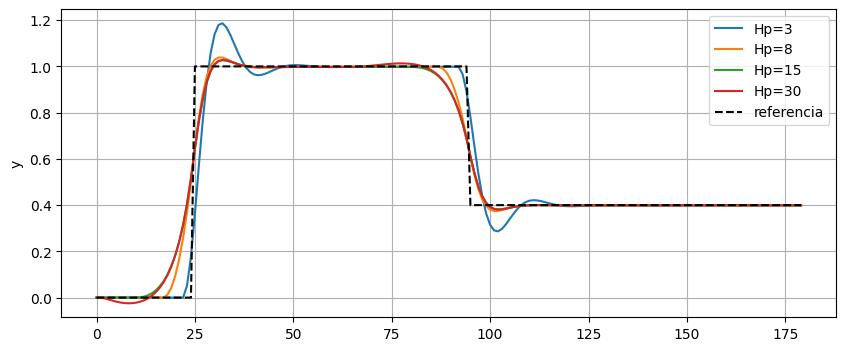

In [9]:
plt.figure(figsize=(10,4))
for Hp in [3, 8, 15, 30]:
    r,y,u,du = simulate_gpc(a_hat,b_hat,lam=1.0,Hp=Hp,Hu=min(3,Hp))
    plt.plot(y,label=f'Hp={Hp}')
plt.plot(r,'k--',label='referencia')
plt.grid(True); plt.legend(); plt.ylabel('y'); plt.show()


### Preguntas para clase

- ¿Existe ventaja en aumentar indefinidamente el horizonte?
- ¿Qué coste computacional tiene?
- ¿Qué sentido tiene predecir muy lejos si el modelo solo es fiable a corto plazo?

<details>
<summary><b>Mostrar respuesta</b></summary>

No existe una ventaja general en aumentar indefinidamente el horizonte.

Un horizonte mayor permite al controlador anticipar mejor dinámicas lentas, retardos o cambios futuros de referencia. Sin embargo:

- aumenta el tamaño del problema de predicción y optimización;
- incrementa el coste computacional;
- puede aportar muy poca mejora una vez que el horizonte cubre suficientemente la dinámica dominante;
- las predicciones lejanas suelen ser menos fiables por incertidumbre de modelo y perturbaciones.

Por tanto, el horizonte debe ser **suficientemente largo para capturar la dinámica relevante**, pero no arbitrariamente grande.

</details>


## 10. Experimento 3 — sensibilidad frente a errores de modelo

En industria el modelo nunca coincide exactamente con la planta. Vamos a separar dos errores que en la versión anterior estaban mezclados:

1. **error de dinámica**, manteniendo la misma ganancia estacionaria;
2. **error de ganancia**, manteniendo aproximadamente la misma dinámica.

Además observaremos simultáneamente $y$ y $u$.

> Seguimos usando primero el predictor ARX simplificado. Todavía **no** incorpora estimación explícita de perturbaciones persistentes.


### 10.1 Error de dinámica manteniendo la ganancia

Para

\begin{align*}
y(k)=a\,y(k-1)+b\,u(k-1)
\end{align*}

la ganancia estacionaria es

\begin{align*}
K=\frac{b}{1-a}.
\end{align*}

Como la planta de la práctica tiene $K=1$, elegimos $b=1-a$ para comparar:

- $(0.65,0.35)$: modelo demasiado rápido;
- $(0.82,0.18)$: modelo aproximadamente correcto;
- $(0.93,0.07)$: modelo demasiado lento.

Así aislamos mucho mejor el efecto de la **dinámica temporal**.


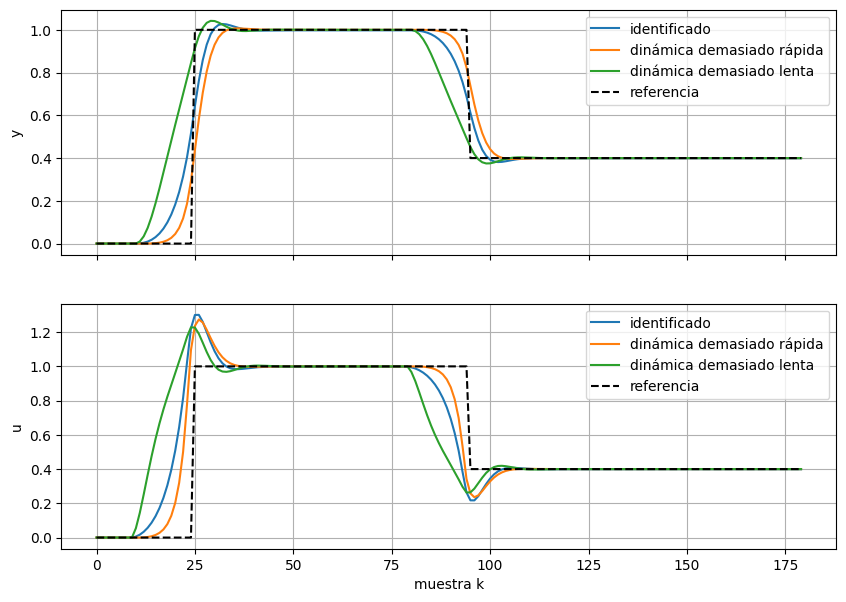

In [10]:
dynamic_models = [
    (a_hat, b_hat, 'identificado'),
    (0.65, 0.35, 'dinámica demasiado rápida'),
    (0.93, 0.07, 'dinámica demasiado lenta')
]

fig, ax = plt.subplots(2, 1, figsize=(10,7), sharex=True)
for am,bm,name in dynamic_models:
    r,y,u,du = simulate_gpc(am,bm,lam=1.0)
    ax[0].plot(y,label=name)
    ax[1].plot(u,label=name)
ax[0].plot(r,'k--',label='referencia')
ax[1].plot(r,'k--',label='referencia')
ax[0].set_ylabel('y'); ax[1].set_ylabel('u'); ax[1].set_xlabel('muestra k')
for aa in ax:
    aa.grid(True); aa.legend()
plt.show()


**Pregunta:** si los tres modelos tienen prácticamente la misma ganancia estacionaria, ¿por qué cambian los transitorios?

<details>
<summary><b>Mostrar respuesta</b></summary>

Porque $a$ determina la memoria y la velocidad que el predictor atribuye al proceso. El optimizador obtiene trayectorias futuras distintas aunque el punto estacionario sea parecido.

Un modelo rápido hace creer al controlador que los efectos desaparecen antes; un modelo lento hace creer que persisten durante más tiempo. Por eso cambian los movimientos iniciales, el tiempo de establecimiento y el sobreimpulso.

</details>


### 10.2 Error de ganancia manteniendo la dinámica

Ahora mantenemos $a\approx0.82$ y cambiamos $b$. Así estudiamos qué ocurre cuando el controlador se equivoca principalmente en **cuánto efecto tiene el actuador sobre la salida**.


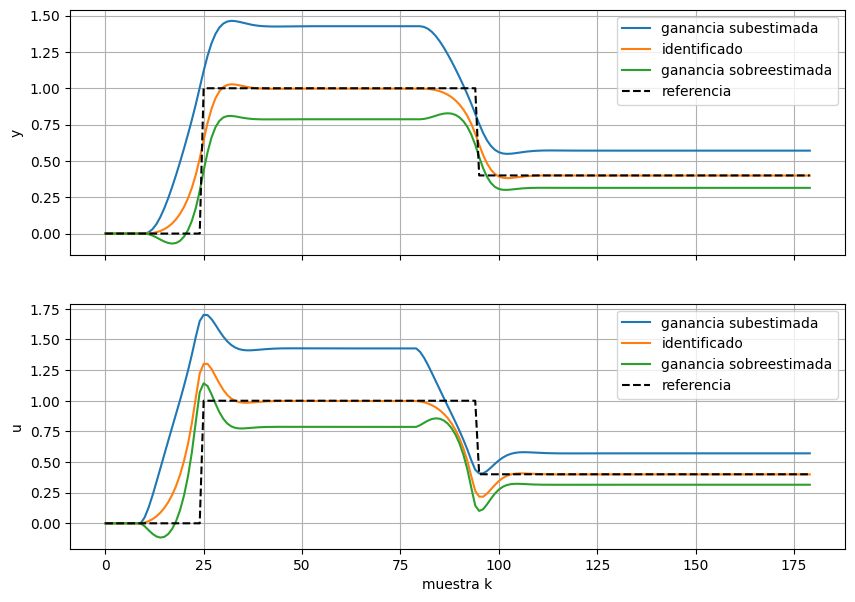

In [11]:
gain_models = [
    (0.82, 0.10, 'ganancia subestimada'),
    (a_hat, b_hat, 'identificado'),
    (0.82, 0.30, 'ganancia sobreestimada')
]

fig, ax = plt.subplots(2, 1, figsize=(10,7), sharex=True)
for am,bm,name in gain_models:
    r,y,u,du = simulate_gpc(am,bm,lam=1.0)
    ax[0].plot(y,label=name)
    ax[1].plot(u,label=name)
ax[0].plot(r,'k--',label='referencia')
ax[1].plot(r,'k--',label='referencia')
ax[0].set_ylabel('y'); ax[1].set_ylabel('u'); ax[1].set_xlabel('muestra k')
for aa in ax:
    aa.grid(True); aa.legend()
plt.show()


**Pregunta:** ¿qué esperas si el controlador subestima la ganancia de la planta?

<details>
<summary><b>Mostrar respuesta</b></summary>

Cree que cada movimiento de $u$ produce poco efecto sobre $y$, por lo que tenderá a solicitar una acción mayor.

Con el predictor simplificado puede alcanzar un equilibrio coherente con **su modelo**, pero distinto del equilibrio real. Por ello puede aparecer **offset estacionario**. Si sobreestima la ganancia ocurre el efecto contrario.

</details>


## 11. El horizonte deslizante no garantiza por sí solo offset cero

En cada muestra medimos $y(k)$ y volvemos a optimizar. Esto corrige la **condición inicial** de la predicción, pero no significa que estemos estimando una perturbación persistente.

El predictor simplificado vuelve a confiar en el modelo nominal para los siguientes pasos.

**Pregunta:** ¿por qué puede mantenerse un error estacionario aunque utilicemos la salida real en cada iteración?

<details>
<summary><b>Mostrar respuesta</b></summary>

Porque actualizar $y(k)$ corrige desde dónde empieza la predicción, pero no corrige el sesgo de todas las predicciones futuras. Si el modelo tiene una ganancia equivocada, el optimizador puede encontrar un equilibrio que considera adecuado aunque $y\neq r$ en la planta real.

Necesitamos un mecanismo adicional que estime la discrepancia persistente y la incorpore al predictor.

</details>


## 12. CARIMA aparece porque necesitamos corregir perturbaciones persistentes

La formulación clásica de GPC utiliza habitualmente un modelo CARIMA:

\begin{align*}
A(z^{-1})y(k)
=
z^{-d}B(z^{-1})u(k-1)
+
\frac{e(k)}{\Delta},
\qquad
\Delta=1-z^{-1}.
\end{align*}

No resolveremos aquí las ecuaciones diofánticas. Lo importante es entender **por qué aparece la parte integrada**: proporciona un marco para representar perturbaciones persistentes y construir predicciones corregidas.

> Primero observamos el problema experimentalmente; después introducimos la matemática que lo resuelve.


## 13. Experimento 3B — compensación offset-free

Construiremos una versión didáctica del principio de compensación. Estimamos en cada instante la discrepancia de una muestra:

\begin{align*}
\hat d(k)=y(k)-\hat y_{\mathrm{nom}}(k|k-1)
\end{align*}

y suponemos que ese sesgo permanece durante el horizonte.

**Nota:** esto ilustra el principio de estimación de perturbación; no sustituye la derivación CARIMA clásica.


In [12]:
def predict_outputs_offset_free(y0, u_prev, du_seq, a, b, Hp, d_hat=0.0):
    y=float(y0); u=float(u_prev); pred=[]
    for j in range(Hp):
        if j < len(du_seq):
            u += du_seq[j]
        y = a*y + b*u + d_hat
        pred.append(y)
    return np.asarray(pred)

def prediction_matrix_offset_free(y,u_prev,a,b,Hp,Hu,d_hat):
    f=predict_outputs_offset_free(y,u_prev,np.zeros(Hu),a,b,Hp,d_hat)
    G=np.zeros((Hp,Hu))
    for j in range(Hu):
        du=np.zeros(Hu); du[j]=1.0
        G[:,j]=predict_outputs_offset_free(y,u_prev,du,a,b,Hp,d_hat)-f
    return f,G

def gpc_move_offset_free(y,u_prev,ref_future,a,b,d_hat,Hp=15,Hu=3,lam=1.0):
    f,G=prediction_matrix_offset_free(y,u_prev,a,b,Hp,Hu,d_hat)
    return np.linalg.solve(G.T@G+lam*np.eye(Hu),G.T@(ref_future-f))[0]

def simulate_gpc_offset_free(a_model,b_model,lam=1.0,Hp=15,Hu=3,
                             a_plant=a_real,b_plant=b_real):
    Nsim=180
    r=np.zeros(Nsim+Hp+1); r[25:95]=1.0; r[95:]=0.4
    y=np.zeros(Nsim); u=np.zeros(Nsim); du=np.zeros(Nsim); d_hat=np.zeros(Nsim)

    for k in range(1,Nsim):
        # Planta real: y(k) depende de u(k-1)
        y[k]=a_plant*y[k-1]+b_plant*u[k-1]

        # Error de predicción de una muestra
        y_nominal=a_model*y[k-1]+b_model*u[k-1]
        d_hat[k]=y[k]-y_nominal

        # Nueva optimización usando la medición actual y el sesgo estimado
        ref_future=r[k+1:k+1+Hp]
        du[k]=gpc_move_offset_free(y[k],u[k-1],ref_future,
                                   a_model,b_model,d_hat[k],Hp,Hu,lam)
        u[k]=u[k-1]+du[k]

    return r[:Nsim],y,u,du,d_hat


### 13.1 Comparación directa con un error de ganancia

Usamos deliberadamente $a_m=0.82$ y $b_m=0.10$. Primero ejecutamos el controlador simplificado y después el predictor con estimación de sesgo.


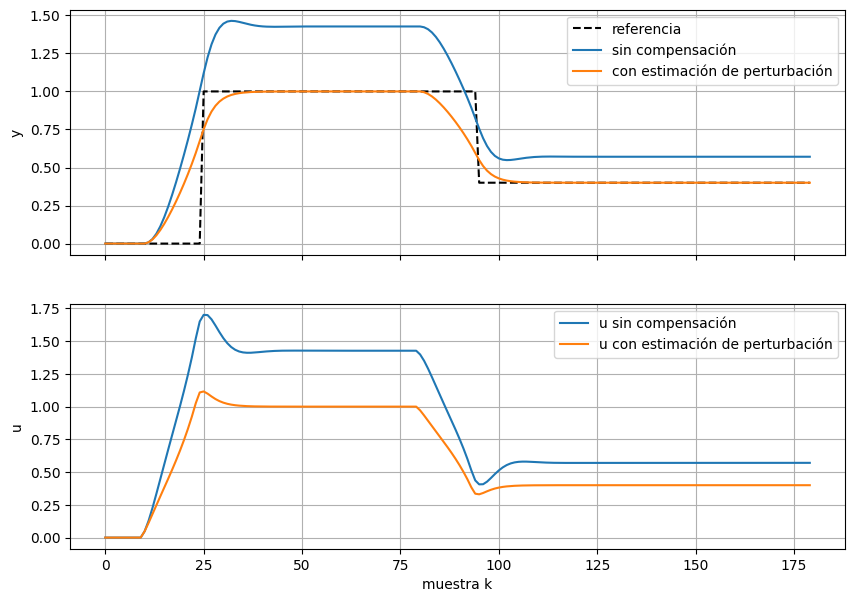

In [13]:
am,bm=0.82,0.10
r,y0,u0,du0=simulate_gpc(am,bm,lam=1.0)
r,y1,u1,du1,dhat=simulate_gpc_offset_free(am,bm,lam=1.0)

fig,ax=plt.subplots(2,1,figsize=(10,7),sharex=True)
ax[0].plot(r,'k--',label='referencia')
ax[0].plot(y0,label='sin compensación')
ax[0].plot(y1,label='con estimación de perturbación')
ax[1].plot(u0,label='u sin compensación')
ax[1].plot(u1,label='u con estimación de perturbación')
ax[0].set_ylabel('y'); ax[1].set_ylabel('u'); ax[1].set_xlabel('muestra k')
for aa in ax:
    aa.grid(True); aa.legend()
plt.show()


**Pregunta:** ¿qué diferencia fundamental esperamos observar?

<details>
<summary><b>Mostrar respuesta</b></summary>

Sin compensación, el error de modelo sesga las predicciones y puede permanecer $y\neq r$.

Con estimación de perturbación, la discrepancia observada se propaga al horizonte:

\begin{align*}
\text{error observado}
\rightarrow
\text{perturbación estimada}
\rightarrow
\text{predicción corregida}
\rightarrow
\text{reducción del offset}.
\end{align*}

Ésta es la idea que queremos conectar posteriormente con CARIMA.

</details>


## 14. Experimento 4 — perturbación constante real

Ahora el modelo es razonable, pero a partir de una determinada muestra aparece una perturbación constante no medida. Compararemos nuevamente ambos predictores.


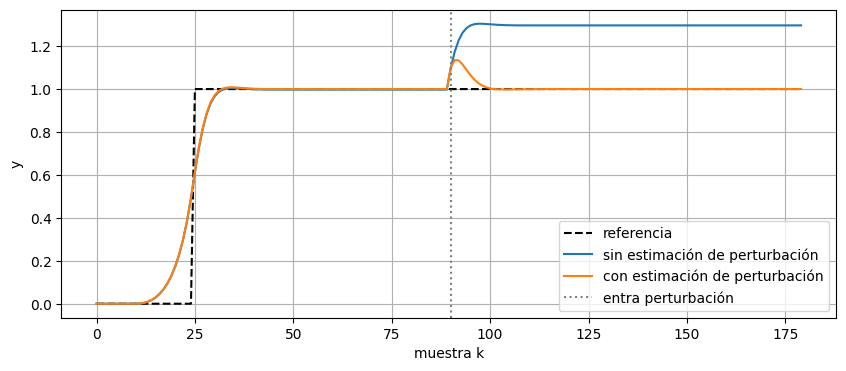

In [14]:
def simulate_constant_disturbance(offset_free=False, disturbance_value=0.10):
    Nsim=180; Hp=15; Hu=3; lam=1.0
    r=np.zeros(Nsim+Hp+1); r[25:]=1.0
    y=np.zeros(Nsim); u=np.zeros(Nsim); du=np.zeros(Nsim)

    for k in range(1,Nsim):
        d=disturbance_value if k>=90 else 0.0
        y[k]=a_real*y[k-1]+b_real*u[k-1]+d
        ref_future=r[k+1:k+1+Hp]

        if offset_free:
            y_nom=a_hat*y[k-1]+b_hat*u[k-1]
            d_hat=y[k]-y_nom
            du[k]=gpc_move_offset_free(y[k],u[k-1],ref_future,
                                       a_hat,b_hat,d_hat,Hp,Hu,lam)
        else:
            du[k],_,_=gpc_move(y[k],u[k-1],ref_future,a_hat,b_hat,Hp,Hu,lam)
        u[k]=u[k-1]+du[k]
    return r[:Nsim],y,u

r,ya,ua=simulate_constant_disturbance(False)
r,yb,ub=simulate_constant_disturbance(True)

plt.figure(figsize=(10,4))
plt.plot(r,'k--',label='referencia')
plt.plot(ya,label='sin estimación de perturbación')
plt.plot(yb,label='con estimación de perturbación')
plt.axvline(90,color='gray',linestyle=':',label='entra perturbación')
plt.ylabel('y'); plt.xlabel('muestra k'); plt.grid(True); plt.legend(); plt.show()


**Pregunta:** ¿por qué esta prueba es especialmente relevante en industria?

<details>
<summary><b>Mostrar respuesta</b></summary>

Porque los procesos reales sufren cambios de carga, condiciones ambientales, composición, presión de suministro, envejecimiento y otras perturbaciones no medidas.

No basta con que el MPC funcione bien con el modelo nominal. Debe detectar discrepancias entre predicción y medida e incorporarlas de forma adecuada para recuperar el objetivo de operación.

</details>


## 15. Extensión — restricciones

En una planta real aparecen límites sobre $u$, $\Delta u$ y $y$. La filosofía MPC no cambia, pero al añadir restricciones normalmente pasamos de la solución analítica a resolver un problema cuadrático (QP) en cada muestra.


## 16. Discusión final MAC–DMC–GPC

| Aspecto | MAC | DMC | GPC |
|---|---|---|---|
| Modelo básico | Respuesta impulso | Respuesta escalón | Modelo paramétrico |
| Variable típica | $u$ | $\Delta u$ | $\Delta u$ |
| Identificación intuitiva | Ensayo impulso | Ensayo escalón | Datos entrada–salida |
| Memoria | FIR | Coeficientes escalón | $A$, $B$ y retardo |
| Perturbaciones persistentes | Requieren tratamiento | Requieren tratamiento | CARIMA proporciona el marco clásico |
| Filosofía MPC | La misma | La misma | La misma |

### Preguntas de cierre

1. ¿Por qué medir $y(k)$ no garantiza por sí solo offset cero?
2. ¿Qué diferencia hay entre error dinámico y error de ganancia?
3. ¿Qué aporta conceptualmente la parte integrada de CARIMA?
4. ¿Un horizonte mayor compensa un modelo pobre?
5. ¿Qué cambia cuando añadimos restricciones?

<details>
<summary><b>Mostrar respuestas</b></summary>

**1.** Actualizar la condición inicial no equivale a estimar una perturbación persistente.

**2.** El primero cambia principalmente la evolución temporal predicha; el segundo cambia cuánto efecto se atribuye a la entrada y puede desplazar el equilibrio previsto.

**3.** Permite representar perturbaciones persistentes y construir predicciones corregidas, bajo las hipótesis del GPC clásico.

**4.** No. Predecir más lejos con un modelo incorrecto no elimina el error de modelo.

**5.** La filosofía permanece; cambia el problema de optimización, que típicamente pasa a formularse como QP en MPC lineal.

</details>
